<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

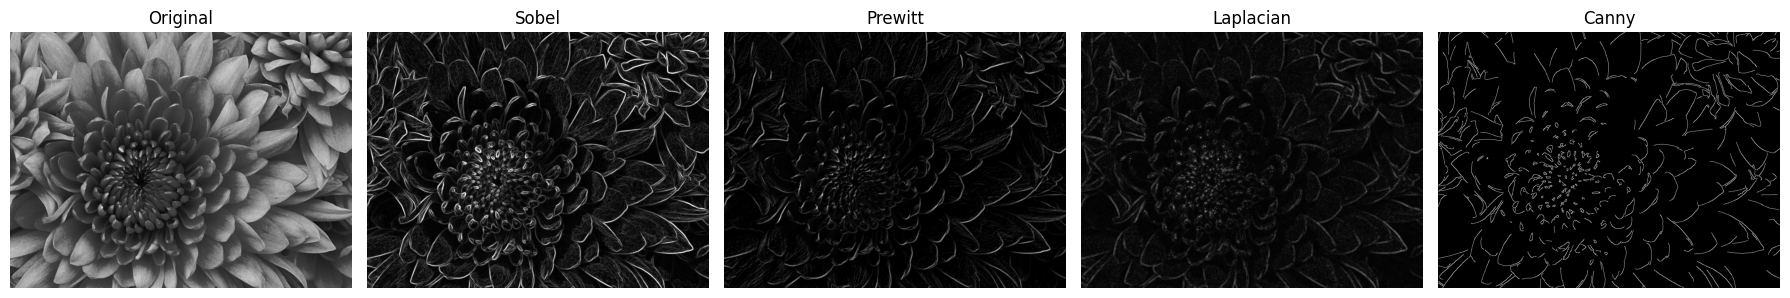

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the filename directly
fn = "test.jpg"

# Ensure the file exists
if not os.path.exists(fn):
    print(f"Error: '{fn}' not found. Please upload it to the Colab files sidebar and refresh.")
else:
    # Load the image in grayscale
    img = cv2.imread(fn, 0)

    if img is None:
        print(f"Error: Could not read '{fn}'. Please ensure it is a valid image file.")
    else:
        # Preprocessing: Gaussian Blur
        blur = cv2.GaussianBlur(img, (5, 5), 0)

        # 1. Sobel Edge Detection
        sobel_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
        sobel_mag = cv2.magnitude(sobel_x, sobel_y)
        sobel_mag = np.uint8(np.clip(sobel_mag, 0, 255))

        # 2. Prewitt Edge Detection
        kernelx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
        kernely = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
        prewitt_x = cv2.filter2D(blur, -1, kernelx)
        prewitt_y = cv2.filter2D(blur, -1, kernely)
        prewitt = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

        # 3. Laplacian Edge Detection
        laplacian = cv2.Laplacian(blur, cv2.CV_64F)
        laplacian = np.uint8(np.clip(np.absolute(laplacian), 0, 255))

        # 4. Canny Edge Detection
        canny = cv2.Canny(blur, 80, 160)

        # Plotting the results
        fig, ax = plt.subplots(1, 5, figsize=(18, 4))
        ax[0].imshow(img, cmap="gray"); ax[0].set_title("Original")
        ax[1].imshow(sobel_mag, cmap="gray"); ax[1].set_title("Sobel")
        ax[2].imshow(prewitt, cmap="gray"); ax[2].set_title("Prewitt")
        ax[3].imshow(laplacian, cmap="gray"); ax[3].set_title("Laplacian")
        ax[4].imshow(canny, cmap="gray"); ax[4].set_title("Canny")

        for a in ax: a.axis("off")
        plt.tight_layout()
        plt.show()

In [ ]:
import os
print("Current Working Directory:", os.getcwd())
print("Files visible in Colab:", os.listdir())

Current Working Directory: /content
Files visible in Colab: ['.config', '.ipynb_checkpoints', ' test.jpg', 'sample_data']
